### Гипотеза 3:  Использование раздельного learning rate для backbone и head улучшит качество модели. (меньший LR для backbone, больший для head)

Импорт библиотек и загрузка результатов экспериментов для сравнения гипотез.

In [ ]:
from common import *
all_results = load_results()

Загрузка параметров обучения и подготовка датасетов с загрузчиками

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка сплитов и подготовки параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
SEED = cfg["seed"] # seed для воспроизводимости
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы изображений для тренировочного набора
val_indices = cfg["val_indices"] # индексы изображений для валидационного набора

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # получение изображений для тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # получение изображений для валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Функция обучения с CosineAnnealing

In [ ]:
def train_model_split_lr(model, model_name, train_loader, val_loader, test_loader, epochs=10, backbone_lr=1e-5, head_lr=1e-3, device=DEVICE):
    """ Обучение модели с раздельным learning rate для backbone и head. """
    set_seed(SEED)
    model = model.to(device) # перенос модели на устройство
    criterion = nn.CrossEntropyLoss() # создание функции потерь

    backbone_params = [] # список параметров для backbone
    head_params = [] # список параметров для head

    for name, param in model.named_parameters(): # перебор параметров модели
        if param.requires_grad: # если параметр требует градиента
            if 'fc' in name or 'head' in name or 'classifier' in name: # если параметр относится к head
                head_params.append(param) # добавление параметра в список параметров для head
            else:
                backbone_params.append(param) # добавление параметра в список параметров для backbone

    # создание оптимизатора с раздельными learning rates для backbone и head
    optimizer = optim.Adam([
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr}
    ])

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # создание scheduler для оптимизатора

    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None # создание scaler для оптимизатора

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # словарь для хранения истории обучения

    for epoch in range(epochs): # перебор эпох
        model.train() # установка модели в режим обучения
        running_loss = 0.0 # инициализация переменной для хранения потерь
        all_preds = [] # список для хранения предсказаний
        all_labels = [] # список для хранения меток

        for images, labels in train_loader: # перебор батчей
            images, labels = images.to(device), labels.to(device) # перенос изображений и меток на устройство
            optimizer.zero_grad() # обнуление градиентов

            if scaler: # если scaler существует
                with torch.amp.autocast('cuda'): # использование автоматического преобразования в float16
                    outputs = model(images) # получение предсказаний модели
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # обратный проход
                scaler.step(optimizer) # шаг оптимизатора
                scaler.update() # обновление масштаба
            else: # если scaler не существует
                outputs = model(images) # получение предсказаний модели
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратный проход
                optimizer.step() # шаг оптимизатора
            
            running_loss += loss.item() * images.size(0) # обновление переменной для хранения потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний модели
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        
        train_loss = running_loss / len(train_loader.dataset) # вычисление среднего потерь
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности

        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка модели на валидационной выборке
        scheduler.step() # обновление learning rate

        history["train_loss"].append(train_loss) # добавление потерь в историю
        history["val_loss"].append(val_loss) # добавление потерь в историю
        history["train_acc"].append(train_acc) # добавление точности в историю
        history["val_acc"].append(val_acc) # добавление точности в историю

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    # оценка модели на тестовой выборке
    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate( 
        model, test_loader, criterion, device
    )

    # вывод результатов на тестовой выборке
    print(f"\n{model_name} -  TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # построение матрицы ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # графики потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # отчёт о классификации
    print(f"{model_name} - Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение результатов
    return {
        "model": model_name,
        "test_acc": test_acc,
        "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1,
        "history": history,
        "confusion_matrix": cm.tolist(),
    }

Обучение модели ResNet18 с раздельными learning rates и сохранение результатов

Epoch 1/10 - Train Loss: 0.6057, Train Acc: 0.7620, Val Loss: 0.1785, Val Acc: 0.9342, Val Bal Acc: 0.9343, Val F1: 0.9343
Epoch 2/10 - Train Loss: 0.1025, Train Acc: 0.9695, Val Loss: 0.0732, Val Acc: 0.9774, Val Bal Acc: 0.9775, Val F1: 0.9775
Epoch 3/10 - Train Loss: 0.0280, Train Acc: 0.9960, Val Loss: 0.0441, Val Acc: 0.9885, Val Bal Acc: 0.9885, Val F1: 0.9885
Epoch 4/10 - Train Loss: 0.0111, Train Acc: 0.9990, Val Loss: 0.0314, Val Acc: 0.9910, Val Bal Acc: 0.9910, Val F1: 0.9910
Epoch 5/10 - Train Loss: 0.0059, Train Acc: 0.9997, Val Loss: 0.0271, Val Acc: 0.9920, Val Bal Acc: 0.9920, Val F1: 0.9920
Epoch 6/10 - Train Loss: 0.0038, Train Acc: 1.0000, Val Loss: 0.0275, Val Acc: 0.9925, Val Bal Acc: 0.9925, Val F1: 0.9925
Epoch 7/10 - Train Loss: 0.0033, Train Acc: 0.9999, Val Loss: 0.0276, Val Acc: 0.9915, Val Bal Acc: 0.9915, Val F1: 0.9915
Epoch 8/10 - Train Loss: 0.0034, Train Acc: 1.0000, Val Loss: 0.0302, Val Acc: 0.9910, Val Bal Acc: 0.9910, Val F1: 0.9910
Epoch 9/10 - Tra

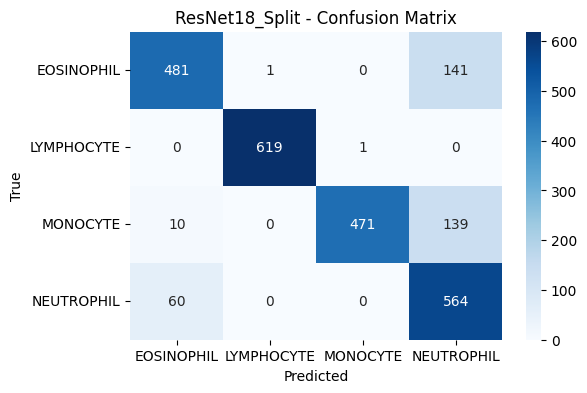

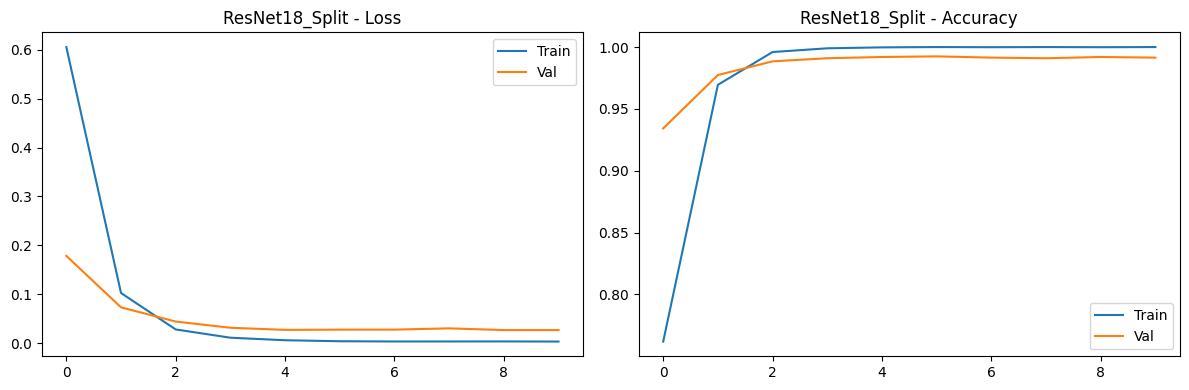

ResNet18_Split - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.87      0.77      0.82       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.76      0.86       620
  NEUTROPHIL       0.67      0.90      0.77       624

    accuracy                           0.86      2487
   macro avg       0.88      0.86      0.86      2487
weighted avg       0.88      0.86      0.86      2487

Resnet18 с раздельными learning rates обучена и сохранена.


In [ ]:
resnet18_split = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # создание модели ResNet18
resnet18_split.fc = nn.Linear(resnet18_split.fc.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

resnet18_split_results = train_model_split_lr(
    resnet18_split,
    "ResNet18_Split",
    train_loader,
    val_loader,
    test_loader,
    epochs=10,
    backbone_lr=1e-5,
    head_lr=1e-3
)

torch.save(resnet18_split.state_dict(), "outputs/resnet18_split.pth") # сохранение модели
print("Resnet18 с раздельными learning rates обучена и сохранена.")

Раздельный learning rate не улучшил результат: Accuracy 0.8585 против baseline 0.8544 — прирост в пределах статистического шума. Гипотеза для ResNet18 не подтвердилась. 

Возможная причина: ResNet18 в данном эксперименте инициализирован предобученными весами ImageNet, которые уже достаточно хорошо настроены. Очень низкий lr для backbone (1e-5) фактически его «заморозил», не давая адаптироваться к специфике гистологических изображений.

Обучение модели Swin-T с раздельными learning rates и сохранение результатов

Epoch 1/10 - Train Loss: 0.3855, Train Acc: 0.8383, Val Loss: 0.0752, Val Acc: 0.9669, Val Bal Acc: 0.9669, Val F1: 0.9669
Epoch 2/10 - Train Loss: 0.0840, Train Acc: 0.9672, Val Loss: 0.0712, Val Acc: 0.9729, Val Bal Acc: 0.9730, Val F1: 0.9729
Epoch 3/10 - Train Loss: 0.0471, Train Acc: 0.9833, Val Loss: 0.0097, Val Acc: 0.9970, Val Bal Acc: 0.9970, Val F1: 0.9970
Epoch 4/10 - Train Loss: 0.0249, Train Acc: 0.9921, Val Loss: 0.0110, Val Acc: 0.9975, Val Bal Acc: 0.9975, Val F1: 0.9975
Epoch 5/10 - Train Loss: 0.0258, Train Acc: 0.9915, Val Loss: 0.0105, Val Acc: 0.9975, Val Bal Acc: 0.9975, Val F1: 0.9975
Epoch 6/10 - Train Loss: 0.0104, Train Acc: 0.9971, Val Loss: 0.0062, Val Acc: 0.9980, Val Bal Acc: 0.9980, Val F1: 0.9980
Epoch 7/10 - Train Loss: 0.0130, Train Acc: 0.9961, Val Loss: 0.0035, Val Acc: 0.9990, Val Bal Acc: 0.9990, Val F1: 0.9990
Epoch 8/10 - Train Loss: 0.0085, Train Acc: 0.9976, Val Loss: 0.0040, Val Acc: 0.9985, Val Bal Acc: 0.9985, Val F1: 0.9985
Epoch 9/10 - Tra

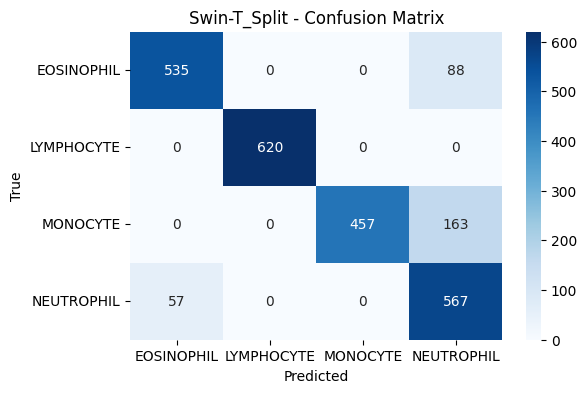

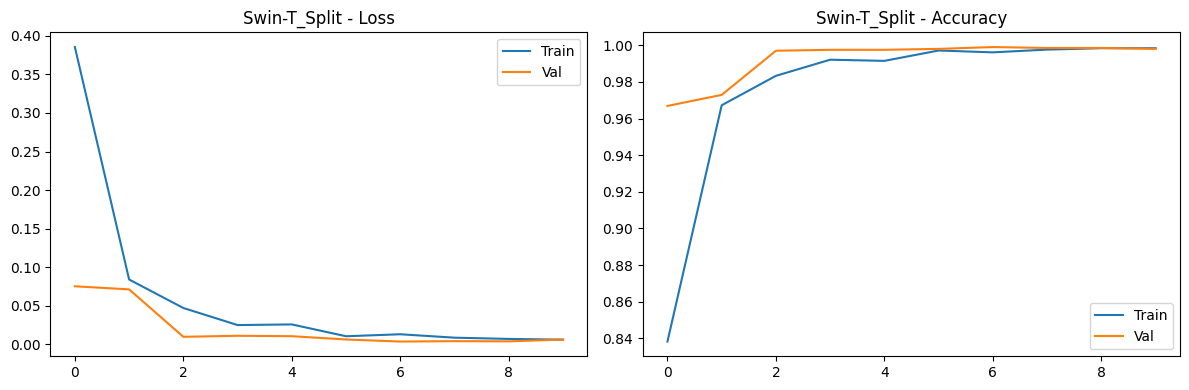

Swin-T_Split - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.90      0.86      0.88       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.74      0.85       620
  NEUTROPHIL       0.69      0.91      0.79       624

    accuracy                           0.88      2487
   macro avg       0.90      0.88      0.88      2487
weighted avg       0.90      0.88      0.88      2487

Swin-T с раздельными learning rates обучена и сохранена.


In [ ]:
swin_split = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создание модели Swin-T
swin_split.head = nn.Linear(swin_split.head.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

swin_split_results = train_model_split_lr(
    swin_split,
    "Swin-T_Split",
    train_loader,
    val_loader,
    test_loader,
    epochs=10,
    backbone_lr=2e-5,
    head_lr=1e-3
)

torch.save(swin_split.state_dict(), "outputs/swin_split.pth") # сохранение модели
print("Swin-T с раздельными learning rates обучена и сохранена.")

Результаты ухудшились по сравнению с baseline: Accuracy 0.8762 против 0.8802. Гипотеза не подтвердилась. Асимметрия LR нарушила согласованное обновление слоёв attention и MLP — для трансформеров, где backbone и head тесно связаны механизмом внимания, такой подход менее обоснован, чем для CNN.

Гипотеза не подтвердилась ни для одной архитектуры. Раздельный LR требует тщательного подбора значений; грубое разделение backbone/head без прогрева и grid-search по lr скорее вредит, чем помогает.